# Boundary Double Cover Of $X(50,60)$

The previous notebook identified 28 circles of binary step-edge optical-flow
patches and saved them as one portable artifact. Here we lift predominant flow
direction from $\mathbb{RP}^1$ to $\mathbb{S}^1$, analyze the resulting circle
bundle, and recover the toroidal coordinates shown in Figure 30 of the paper.

The scientific workflow remains visible through direct `circle_bundles` calls.
The preserved legacy notebook remains unchanged as a provenance source.


## Publication-Scale Analysis

This notebook intentionally has one canonical workflow. It uses the complete
55,501-patch boundary artifact produced by Notebook 02, including the 500
deterministic bridge patches needed to complete two composite circles. The
component memberships and figure layout are specific to the paper dataset.


In [1]:
from __future__ import annotations

import hashlib
import json
import os
import platform
import subprocess
from datetime import datetime, timezone
from pathlib import Path

import circle_bundles as cb
import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().resolve()
if not (ROOT / "data").is_dir() and (ROOT.parent / "data").is_dir():
    ROOT = ROOT.parent

random_seed = 0
n_landmarks = 16
overlap = 1.5
local_rips_points = 500

figure_dir = ROOT / "results" / "paper" / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

print("Running the publication-scale boundary analysis.")

/Users/bradturow/.matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /var/folders/fn/2lq73hwx5lg6l_1s8j7hv2m00000gn/T/matplotlib-1o9cm2v5 because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


Running the publication-scale boundary analysis.


## Load The Portable Boundary Artifact

In [2]:
artifact_path = Path(
    os.environ.get(
        "OPTICAL_FLOW_BOUNDARY_INPUT",
        ROOT / "data" / "K_50_60_Circles.v1.npz",
    )
).expanduser()
if not artifact_path.is_file():
    raise RuntimeError(
        f"Boundary artifact not found: {artifact_path}. Run Notebook 02 first."
    )

with np.load(artifact_path, allow_pickle=False) as archive:
    data = np.asarray(archive["patches"], dtype=np.float64)
    C_circ = np.asarray(archive["memberships"], dtype=bool)
    source_indices = np.asarray(archive["source_indices"], dtype=np.int64)
    boundary_metadata = json.loads(archive["metadata_json"].item())

expected_shape = (boundary_metadata["circle_count"], len(data))
if C_circ.shape != expected_shape:
    raise RuntimeError(
        f"Expected membership shape {expected_shape}; found {C_circ.shape}."
    )
if not np.all(C_circ.sum(axis=0) == 1):
    raise RuntimeError("Every boundary patch must belong to exactly one circle.")

empirical_count = int(np.sum(source_indices >= 0))
synthetic_count = int(np.sum(source_indices == -1))
if empirical_count != boundary_metadata["empirical_patch_count"]:
    raise RuntimeError("Empirical patch count does not match artifact metadata.")
if synthetic_count != boundary_metadata["synthetic_patch_count"]:
    raise RuntimeError("Synthetic patch count does not match artifact metadata.")

predom_dirs, ratios = cb.get_predominant_dirs(data)
patch_vis = cb.make_patch_visualizer()

print(f"Sample contains {len(data):,} high-contrast optical flow patches.")
print(f"Empirical patches: {empirical_count:,}")
print(f"Synthetic bridge patches: {synthetic_count:,}")
print(f"A total of {len(C_circ)} circular clusters.")


Sample contains 55,501 high-contrast optical flow patches.
Empirical patches: 55,001
Synthetic bridge patches: 500
A total of 28 circular clusters.


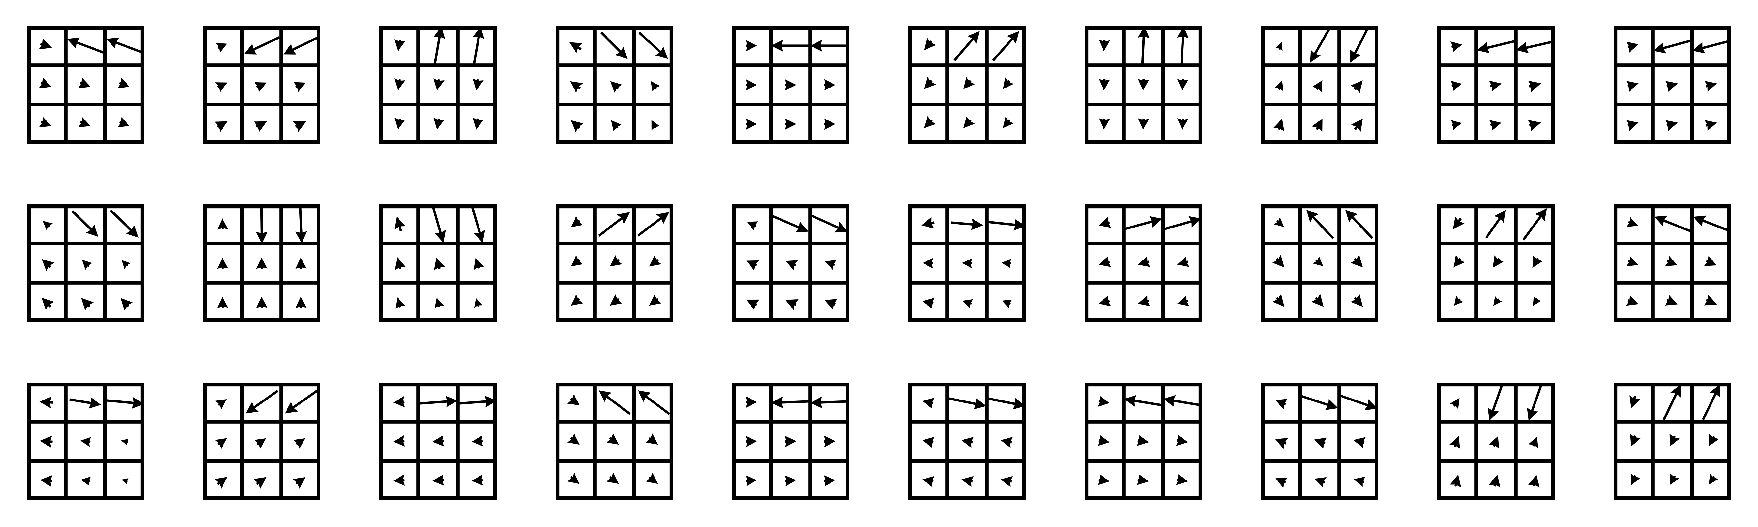

In [3]:
#Show a deterministic sample from one circular cluster
j = 17
circle_data = data[C_circ[j]]
sample_indices = np.linspace(0, len(circle_data) - 1, 30, dtype=int)

fig, axes = cb.show_data_vis(
    circle_data[sample_indices],
    patch_vis,
    sampling_method=None,
    max_samples=30,
    n_cols=10,
    figsize_per_cell=1.2,
)
plt.show()


# Lifting The Step-Edge Circles

Predominant direction normally lives in $\mathbb{RP}^1$, since an axis does not
distinguish a vector from its negative. On these step-edge circles we can lift
the projection by using the direction of the patch's largest flow vector. This
produces a map to $\mathbb{S}^1$.

We use 16 equally spaced angular landmarks and `cb.S1AngleMetric()` directly.
The radius is `1.5` times half the angular landmark spacing. This is the
clean current formulation of the cover; the executed legacy notebook instead
used Euclidean chord distance with an overlap factor of `1.49`.


In [4]:
#Compute lifted predominant directions in S1
lifted_base_points = cb.get_lifted_predominant_dirs(data, eps=1e-12)
lifted_angles = np.mod(
    np.arctan2(lifted_base_points[:, 1], lifted_base_points[:, 0]),
    2*np.pi,
)

landmarks = np.linspace(0, 2*np.pi, n_landmarks, endpoint=False).reshape(-1, 1)
radius = overlap*np.pi/n_landmarks

lifted_cover = cb.get_metric_ball_cover(
    lifted_angles.reshape(-1, 1),
    landmarks,
    radius=radius,
    metric=cb.S1AngleMetric(),
)

print(f"Fiber cardinalities: {lifted_cover.U.sum(axis=1).tolist()}")

Fiber cardinalities: [7337, 4116, 3382, 3103, 6517, 3129, 4155, 8014, 6938, 4093, 3263, 2893, 5501, 3302, 4415, 8488]


## Local Fiber Diagnostics

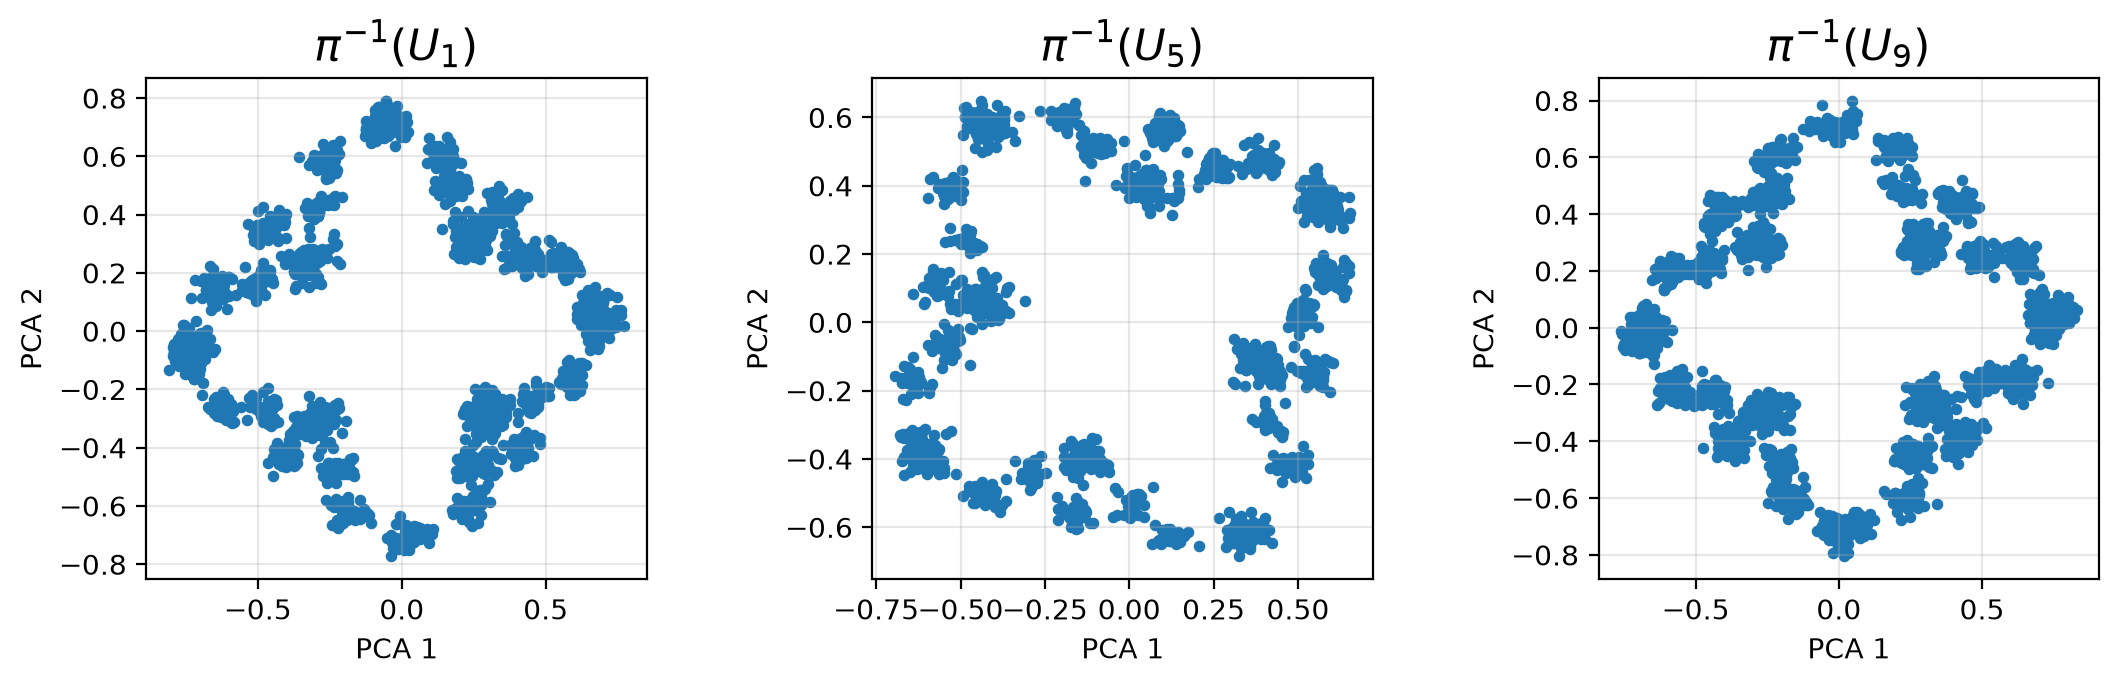

In [5]:
#Show PCA projections of three lifted fibers
fig, axes = cb.get_local_pca(
    data,
    lifted_cover.U,
    to_view=[1, 5, 9],
)
plt.show()

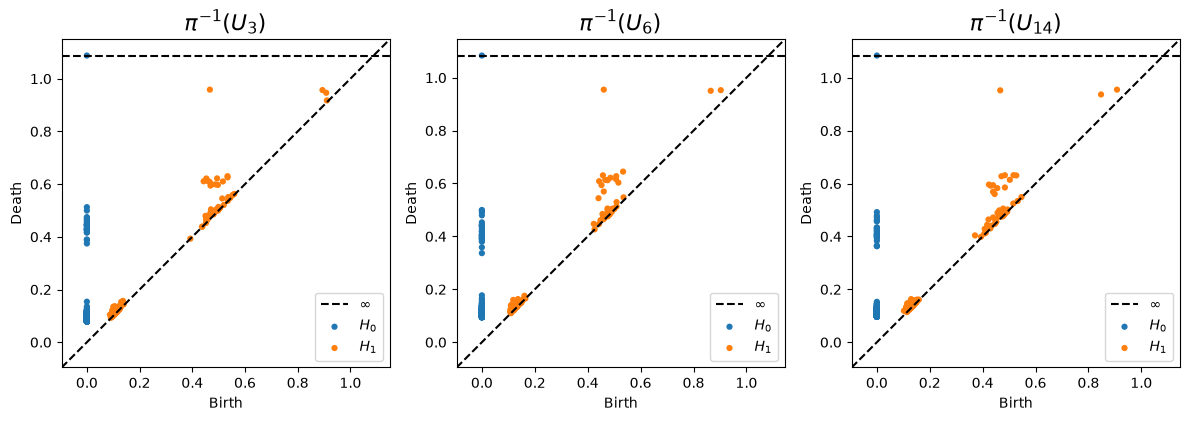

In [6]:
#Compute local 1-D persistence
to_view = [3, 6, 14]
fiber_ids, dense_idx_list, rips_list = cb.get_local_rips(
    data,
    lifted_cover.U,
    to_view=to_view,
    maxdim=1,
    n_perm=local_rips_points,
    random_state=random_seed,
)

fig, axes = cb.plot_local_rips(
    fiber_ids,
    rips_list,
    n_cols=3,
    titles="default",
    font_size=16,
)
plt.show()


# Bundle Analysis

We now compute circular coordinates independently on the lifted fibers, align
them across overlaps, and classify the resulting circle bundle. The paper's
claim is that this lifted bundle is orientable and has zero Euler class, hence
admits a global circle coordinate.


In [7]:
#Construct the circle-bundle analysis object
lifted_bundle = cb.Bundle(
    X=data,
    cover=lifted_cover,
)

print(f"Cover sets: {lifted_bundle.n_sets}")


Cover sets: 16


<IPython.core.display.Math object>

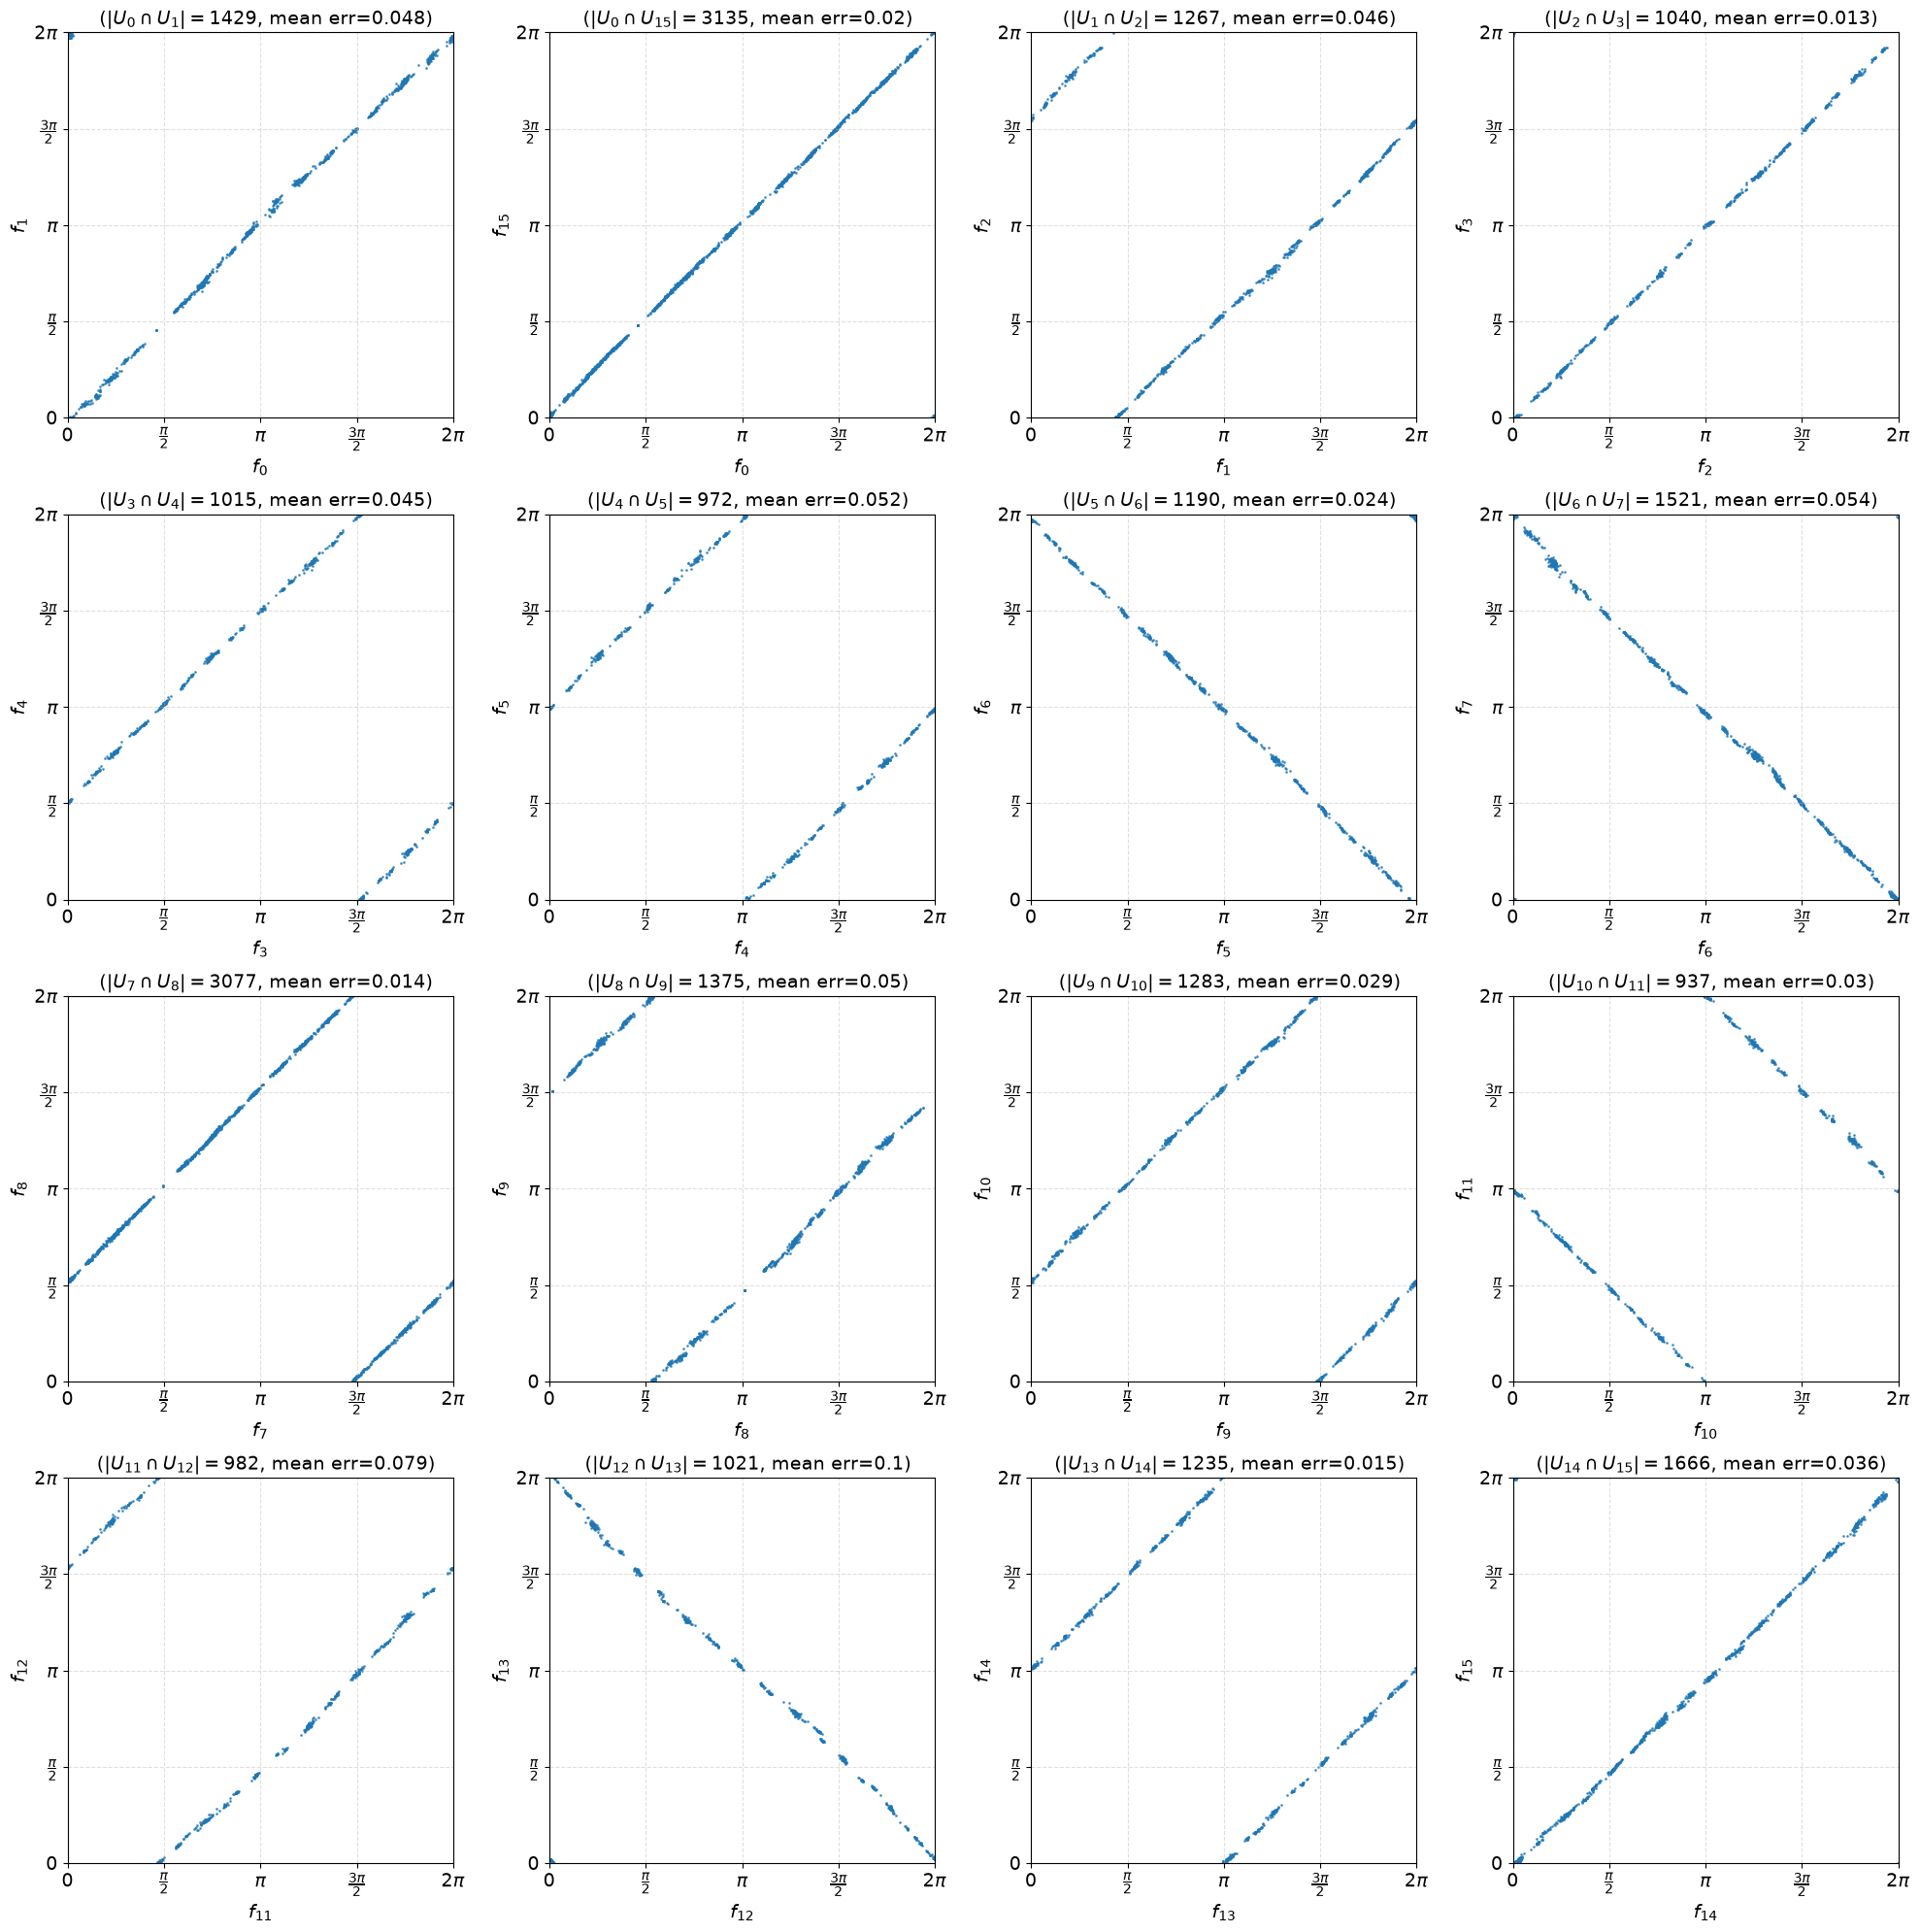

In [8]:
#Compute local trivializations and compare them on all 16 fibers
local_triv_result = lifted_bundle.get_local_trivs(
    show_summary=True,
    verbose=False,
)

fig = lifted_bundle.compare_trivs()
plt.show()


In [9]:
#Compute characteristic classes and a global fiber coordinate
class_result = lifted_bundle.get_classes(show_classes=True)
fiber_angles = lifted_bundle.get_global_trivialization(
    pou=lifted_cover.pou,
)

euler_values = np.asarray(
    list(class_result.reps.euler_class.values()),
    dtype=int,
)
euler_class_zero = bool(
    len(euler_values) == 0 or np.all(euler_values == 0)
)
stiefel_whitney_class_zero = bool(
    class_result.restricted.sw1_is_coboundary_Z2
)

<IPython.core.display.Math object>

## Recovered Boundary Torus (Figure 30)

The horizontal coordinate is lifted predominant direction and the vertical
coordinate is the globally aligned fiber coordinate. Circular coordinates have
no preferred origin or orientation, so a rerun may translate or reflect the
displayed torus without changing the recovered bundle.


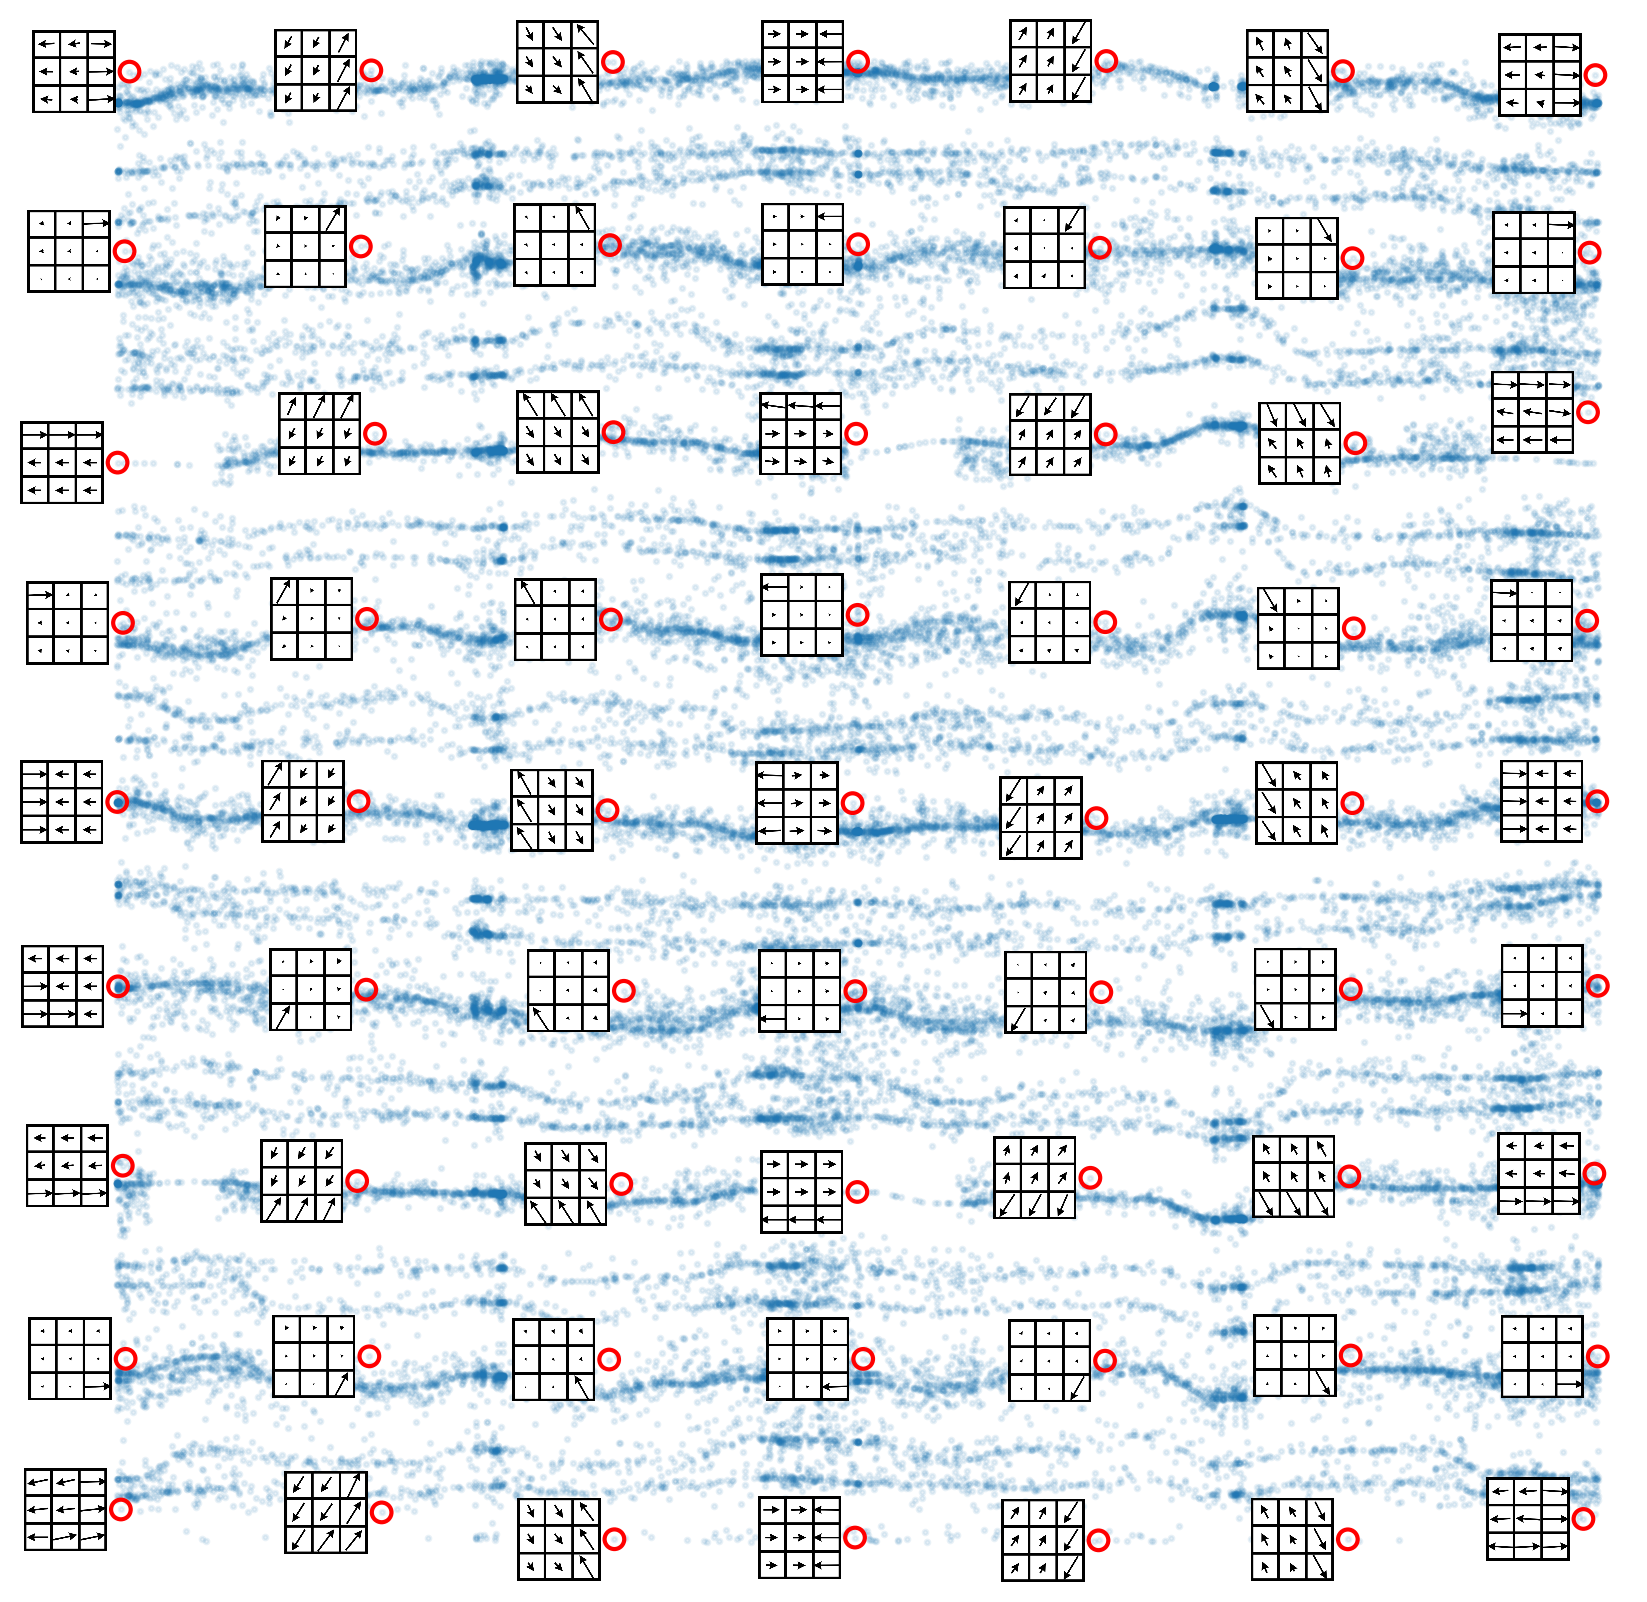

Saved Figure 30 to /Users/bradturow/Desktop/optical_flow_paper/results/paper/figures/boundary_torus.pdf


In [10]:
#Show a sample of globally coordinatized data
coords = np.column_stack((lifted_angles, fiber_angles))
boundary_torus_path = figure_dir / "boundary_torus.pdf"

fig = cb.scatter_lattice_vis(
    data,
    coords,
    patch_vis,
    per_row=7,
    per_col=9,
    padding=0,
    figsize=10,
    save_path=str(boundary_torus_path),
)
plt.show()

print(f"Saved Figure 30 to {boundary_torus_path}")


## Optional Interactive View

For exploratory work, the bundle can also be opened in the interactive viewer:

```python
app = lifted_bundle.show_bundle(colors=fiber_angles)
```

The interactive server is intentionally not started during the reproducible
paper run because it would block headless notebook execution.


## Reproduction Record

In [11]:
def file_sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for block in iter(lambda: stream.read(1024*1024), b""):
            digest.update(block)
    return digest.hexdigest()


def git_value(*args):
    try:
        return subprocess.check_output(
            ["git", *args],
            cwd=ROOT,
            text=True,
            stderr=subprocess.DEVNULL,
        ).strip()
    except (OSError, subprocess.CalledProcessError):
        return None


quality = local_triv_result.quality
metrics = {
    "boundary_patch_count": len(data),
    "circle_count": len(C_circ),
    "empirical_patch_count": empirical_count,
    "synthetic_patch_count": synthetic_count,
    "lifted_cover_sets": n_landmarks,
    "lifted_cover_cardinalities": (
        lifted_cover.U.sum(axis=1).astype(int).tolist()
    ),
    "local_trivialization": {
        "maximum_geodesic_error": float(quality.eps_align_geo),
        "mean_geodesic_error": float(quality.eps_align_geo_mean),
        "surjectivity_defect": float(quality.delta),
        "stability_ratio": float(quality.alpha),
        "cocycle_defect": float(quality.cocycle_defect),
        "maximum_edge_rms_error": float(quality.max_edge_rms),
        "estimated_edges": int(quality.n_edges_estimated),
        "nerve_triangles": int(quality.n_triangles),
    },
    "stiefel_whitney_class_zero": stiefel_whitney_class_zero,
    "euler_class_zero": euler_class_zero,
    "global_coordinate_count": len(fiber_angles),
}

run_record = {
    "experiment": "lifted boundary circle bundle of X(50,60)",
    "profile": "paper",
    "parameters": {
        "cover_landmarks": n_landmarks,
        "cover_metric": "S1AngleMetric",
        "overlap": overlap,
        "cover_radius": float(radius),
        "local_rips_points": local_rips_points,
        "random_seed_for_new_sampling": random_seed,
    },
    "metrics": metrics,
    "outputs": {
        "boundary_torus": str(boundary_torus_path.relative_to(ROOT)),
    },
    "provenance": {
        "notebook": "notebooks/03_boundary_double_cover.ipynb",
        "input_artifact": {
            "filename": artifact_path.name,
            "sha256": file_sha256(artifact_path),
            "metadata": boundary_metadata,
        },
        "figure_sha256": file_sha256(boundary_torus_path),
        "repository_commit": git_value("rev-parse", "HEAD"),
        "repository_had_uncommitted_changes": bool(
            git_value("status", "--porcelain")
        ),
        "generated_at_utc": datetime.now(timezone.utc).isoformat(),
        "python_version": platform.python_version(),
        "numpy_version": np.__version__,
        "circle_bundles_version": getattr(cb, "__version__", "unknown"),
    },
    "known_provenance_notes": [
        (
            "The legacy lifted cover used Euclidean chord distance with "
            "overlap 1.49. This workflow uses S1 angular distance directly "
            "with overlap 1.5, so individual cover memberships can differ."
        ),
        (
            "Global circular coordinates are defined only up to rotation and "
            "reflection, so the plotted torus may differ by a gauge change."
        ),
    ],
}

record_path = ROOT / "results" / "paper" / "boundary_double_cover_run.json"
record_path.parent.mkdir(parents=True, exist_ok=True)
record_path.write_text(json.dumps(run_record, indent=2, sort_keys=True) + "\n")

metrics_path = ROOT / "results" / "paper" / "boundary_double_cover_metrics.json"
metrics_path.write_text(json.dumps(metrics, indent=2, sort_keys=True) + "\n")

print(f"Wrote reproduction record to {record_path}")
run_record


Wrote reproduction record to /Users/bradturow/Desktop/optical_flow_paper/results/paper/boundary_double_cover_run.json


{'experiment': 'lifted boundary circle bundle of X(50,60)',
 'profile': 'paper',
 'parameters': {'cover_landmarks': 16,
  'cover_metric': 'S1AngleMetric',
  'overlap': 1.5,
  'cover_radius': 0.2945243112740431,
  'local_rips_points': 500,
  'random_seed_for_new_sampling': 0},
 'metrics': {'boundary_patch_count': 55501,
  'circle_count': 28,
  'empirical_patch_count': 55001,
  'synthetic_patch_count': 500,
  'lifted_cover_sets': 16,
  'lifted_cover_cardinalities': [7337,
   4116,
   3382,
   3103,
   6517,
   3129,
   4155,
   8014,
   6938,
   4093,
   3263,
   2893,
   5501,
   3302,
   4415,
   8488],
  'local_trivialization': {'maximum_geodesic_error': 0.26283635740822986,
   'mean_geodesic_error': 0.03654977696203869,
   'surjectivity_defect': 0.0,
   'stability_ratio': 0.2620804474954658,
   'cocycle_defect': 0.0,
   'maximum_edge_rms_error': 0.11709037733644272,
   'estimated_edges': 16,
   'nerve_triangles': 0},
  'stiefel_whitney_class_zero': True,
  'euler_class_zero': True,
 